# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Ni Putu Alya Noviyanti]
- **Email:** [alya.noviyanti04@gmail.com]
- **ID Dicoding:** [alyanoviyanti]

## Menentukan Pertanyaan Bisnis

- Pada jam berapa jumlah peminjaman sepeda paling tinggi dan paling rendah?
- Hari apa dalam seminggu yang memiliki tingkat peminjaman sepeda tertinggi dan terendah?
- Musim apa yang menghasilkan jumlah peminjaman sepeda terbanyak dan tersedikit?
- Bulan apa yang menunjukkan tingkat peminjaman sepeda tertinggi dan terendah?
- Bagaimana perbandingan jumlah pengguna terdaftar (registered) dan pengguna kasual (casual) dalam peminjaman sepeda?
- Pada kombinasi bulan dan tahun apa jumlah peminjaman sepeda mencapai puncaknya sebagai indikator periode paling menguntungkan bagi pemilik layanan sewa sepeda?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Dataset yang digunakan dalam proyek analisis ini terdiri dari dua tabel utama, yaitu `day.csv` dan `hour.csv`, yang merepresentasikan data peminjaman sepeda berdasarkan skala waktu harian dan per jam. `day.csv` berisi data agregat peminjaman sepeda per hari, sedangkan `hour.csv` menyediakan data peminjaman sepeda per jam dalam satu hari. Kedua dataset memiliki struktur atribut yang hampir serupa, termasuk informasi waktu (tanggal, bulan, tahun, jam), kondisi cuaca, serta jumlah pengguna terdaftar (registered) dan pengguna kasual (casual). Perbedaan utama terletak pada tingkat granularitas waktu, di mana `hour.csv` merupakan hasil pemecahan data harian menjadi 24 interval waktu per hari.

### Assessing Data

In [ ]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Insight:**

Dataset `day_df` terdiri dari 731 baris yang merepresentasikan data peminjaman sepeda harian selama dua tahun (2011–2012).

Dataset `hour_df` memiliki 17.379 baris, yang merupakan data peminjaman sepeda per jam, menunjukkan bahwa setiap data harian diuraikan menjadi 24 interval waktu.

Mayoritas kolom bertipe numerik (`int64` dan `float64`), sementara kolom tanggal (`dteday`) masih bertipe `object`.

In [ ]:
day_df.isna().sum()
print("Jumlah duplikat day_df: " , day_df.duplicated().sum())
hour_df.isna().sum()
print("Jumlah duplikat hour_df: " , hour_df.duplicated().sum())

Jumlah duplikat day_df:  0
Jumlah duplikat hour_df:  0


**Insight:**

Hasil pengecekan menunjukkan bahwa pada dataset tidak terdapat nilai kosong (missing values) dan juga tidak ditemukan data duplikat baik pada `day_df` maupun `hour_df`. Ketiadaan missing value dan duplikasi menunjukkan bahwa dataset memiliki kualitas data yang sangat baik, sehingga proses pembersihan data dapat difokuskan pada transformasi dan standarisasi, bukan penanganan data hilang.

In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Cleaning Data

In [ ]:
day_df.drop(['workingday', 'instant'], axis=1, inplace=True)
hour_df.drop(['workingday', 'instant'], axis=1, inplace=True)

**Insight:**

Pada tahap ini, dilakukan penghapusan kolom yang tidak relevan, yaitu `workingday` dan `instant`.

Kolom `instant` hanya berfungsi sebagai ID urutan data dan tidak memiliki makna analitis, sehingga aman untuk dihapus.

Kolom `workingday` dihapus karena informasinya sudah dapat direpresentasikan oleh kombinasi kolom weekday dan holiday.

Penghapusan kolom ini membantu menyederhanakan dataset dan mengurangi redundansi fitur.

In [ ]:
day_df.rename(columns={'yr': 'year','mnth': 'month','dteday': 'date','cnt': 'count'}, inplace=True)
hour_df.rename(columns={'yr': 'year','mnth': 'month','dteday': 'date', 'hr': 'hour', 'cnt': 'count'}, inplace=True)

**Insight:**

Pada tahap ini dilakukan pengubahan nama kolom, dengan tujuan mempermudah keterbacaan dan konsistensi nama kolom.

In [ ]:
day_df['date'] = pd.to_datetime(day_df['date'])
hour_df['date'] = pd.to_datetime(hour_df['date'])

categorical_cols = ['season', 'year', 'month', 'holiday', 'weekday', 'weathersit']
for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

In [ ]:
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Misty', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}
weekday_map = {
    0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday',
    4:'Thursday', 5:'Friday', 6:'Saturday'
}
month_map = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}
year_map = {0:2011, 1:2012}

for df in [day_df, hour_df]:
    df['season'] = df['season'].map(season_map)
    df['weathersit'] = df['weathersit'].map(weather_map)
    df['weekday'] = df['weekday'].map(weekday_map)
    df['month'] = df['month'].map(month_map)
    df['year'] = df['year'].map(year_map)

In [ ]:
day_df['hum'] = day_df['hum'] * 100
hour_df['hum'] = hour_df['hum'] * 100

def classify_humidity(h):
    if h < 45:
        return 'Terlalu Kering'
    elif h < 65:
        return 'Ideal'
    else:
        return 'Terlalu Lembab'

day_df['humidity_level'] = day_df['hum'].apply(classify_humidity)
hour_df['humidity_level'] = hour_df['hum'].apply(classify_humidity)

**Insight:**

Pada tahap ini, dilakukan pengubahan tipe data, dimana kolom `date` diubah ke tipe datetime, sedangkan kolom `season, year, month, holiday, weekday, `dan `weathersit` diubah ke bentuk kategorikal. Setelah pengubahan bentuk data, dilakukan juga normalisasi nilai kelembapan lengkap dengan feature engineering kategori tingkat kelembapan yang dibagi menjadi 3, yaitu terlalu kering, ideal, dan terlalu lembab.


## Exploratory Data Analysis (EDA)

### Explore Data `hour_df`

In [ ]:
hour_df.describe(include="all")

,date,season,year,month,hour,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,count,humidity_level
count,17379,17379,17379.0,17379,17379.000000,17379.0,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
unique,NaN,4,2.0,12,NaN,2.0,7,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,Fall,2012.0,Jul,NaN,0.0,Saturday,Clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Terlalu Lembab
freq,NaN,4496,8734.0,1488,NaN,16879.0,2512,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8356
mean,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,0.496987,0.475775,62.722884,0.190098,35.676218,153.786869,189.463088,NaN
min,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,0.340000,0.333300,48.000000,0.104500,4.000000,34.000000,40.000000,NaN
50%,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,0.500000,0.484800,63.000000,0.194000,17.000000,115.000000,142.000000,NaN
75%,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,0.660000,0.621200,78.000000,0.253700,48.000000,220.000000,281.000000,NaN
max,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,1.000000,1.000000,100.000000,0.850700,367.000000,886.000000,977.000000,NaN


**Insight:**

Berdasarkan rangkuman parameter statistik di atas, diperoleh informasi bahwa jumlah pelanggan adalah sebanyak 17379 dengan data peminjaman sepeda per jam menunjukkan variasi yang cukup tinggi yaitu sebesar 189 peminjaman per jam. Berdasarkan data yang ditampilkan juga, range peminjaman sepeda adalah berkisar pada jam 00.00 hingga 23.00, dengan rata-rata penyewaan sepeda terjadi pada jam 11.54.

In [ ]:
hourly_usage = (hour_df.groupby('hour')['count'].sum())
hourly_usage

,count
hour,
0,39130
1,24164
2,16352
3,8174
4,4428
5,14261
6,55132
7,154171
8,261001


**Insight:**

Jam peminjaman tertinggi terjadi pada pukul 17.00 dengan total 336.860 peminjaman, diikuti pukul 18.00 dan 08.00. Sebaliknya, jam terendah terjadi pada pukul 04.00 dengan hanya 4.428 peminjaman, menunjukkan minimnya aktivitas pada dini hari.

In [ ]:
weekday_usage = (hour_df.groupby('weekday')['count'].sum())
weekday_usage

/tmp/ipython-input-946021542.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_usage = (hour_df.groupby('weekday')['count'].sum())


,count
weekday,
Sunday,444027
Monday,455503
Tuesday,469109
Wednesday,473048
Thursday,485395
Friday,487790
Saturday,477807


**Insight:**

Hari Jumat mencatat jumlah peminjaman tertinggi dengan 487.790 peminjaman, sementara hari Minggu menjadi yang terendah. Hal ini menunjukkan penggunaan sepeda lebih dominan pada hari kerja dibandingkan akhir pekan.

In [ ]:
season_usage = (day_df.groupby('season')['count'].sum())
season_usage

/tmp/ipython-input-1651910580.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_usage = (day_df.groupby('season')['count'].sum())


,count
season,
Spring,471348
Summer,918589
Fall,1061129
Winter,841613


**Insight:**

Musim Fall atau musim gugur menjadi periode dengan peminjaman tertinggi, yaitu sebesar 1.061.129, sedangkan musim Spring atau musim semi merupakan musim peminjaman sepeda terendah dengan 471.348 peminjaman. Ini mengindikasikan adanya pola musiman yang kuat dalam penggunaan layanan sepeda.

In [ ]:
monthly_usage = (hour_df.groupby('month')['count'].sum())
monthly_usage

/tmp/ipython-input-1432719107.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_usage = (hour_df.groupby('month')['count'].sum())


,count
month,
Jan,134933
Feb,151352
Mar,228920
Apr,269094
May,331686
Jun,346342
Jul,344948
Aug,351194
Sep,345991


**Insight:**

Bulan Agustus mencatat peminjaman tertinggi sebanyak 351.194, sementara Januari merupakan bulan peminjaman terendah dengan 134.933. Peminjaman cenderung meningkat pada pertengahan tahun dibandingkan awal tahun.

In [ ]:
user_type = hour_df[['registered', 'casual']].sum()
user_type

,0
registered,2672662
casual,620017


**Insight:**

Pengguna terdaftar mendominasi peminjaman dengan total 2.672.662, jauh lebih tinggi dibandingkan pengguna kasual sebanyak 620.017. Hal ini menunjukkan bahwa pelanggan loyal menjadi penopang utama bisnis sewa sepeda.

In [ ]:
monthly_yearly = (hour_df.groupby(['year', 'month'])['count'].sum().reset_index())
monthly_yearly

/tmp/ipython-input-223133586.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_yearly = (hour_df.groupby(['year', 'month'])['count'].sum().reset_index())


,year,month,count
0,2011,Jan,38189
1,2011,Feb,48215
2,2011,Mar,64045
3,2011,Apr,94870
4,2011,May,135821
5,2011,Jun,143512
6,2011,Jul,141341
7,2011,Aug,136691
8,2011,Sep,127418
9,2011,Oct,123511


**Insight:**

Kombinasi bulan dan tahun dengan peminjaman tertinggi terjadi pada September 2012 dengan total 218.573 peminjaman. Periode ini dapat dianggap sebagai waktu paling menguntungkan bagi pemilik layanan sewa sepeda. Selain itu, kita juga dapat melihat adanya penurunan jumlah order yang cukup signifikan pada bulan November dan Desember.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada jam berapa jumlah peminjaman sepeda paling tinggi dan paling rendah?

In [ ]:
sum_hours_df = (hour_df.groupby("hour")["count"].sum().sort_values(ascending=False).reset_index())

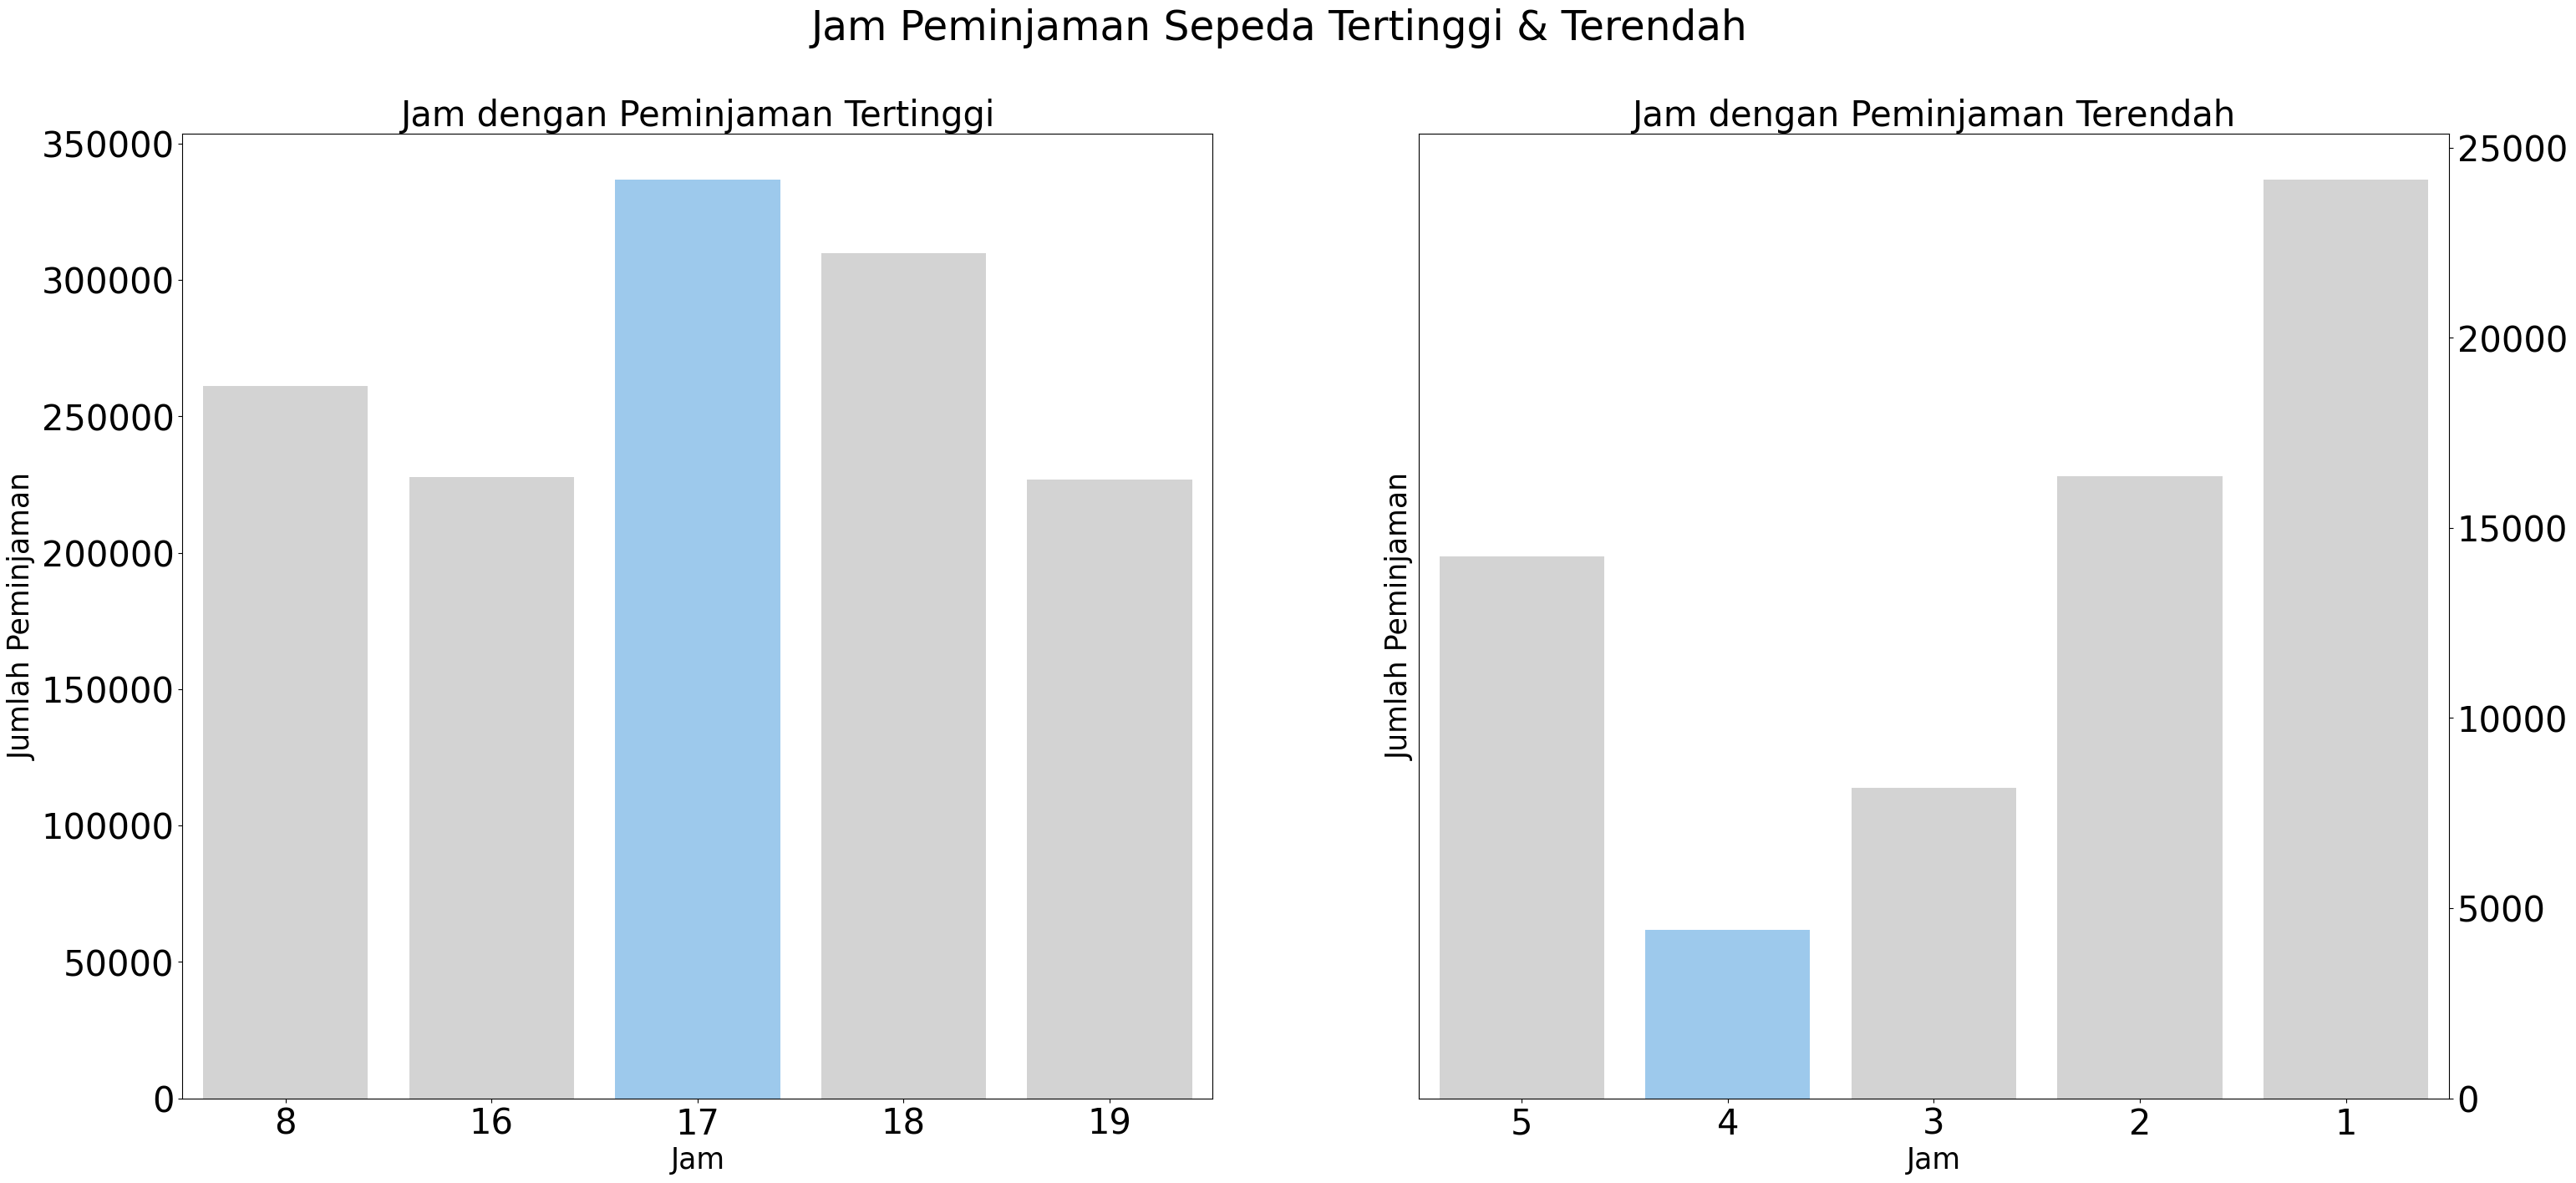

In [ ]:
top_hours = sum_hours_df.sort_values("count", ascending=False).head(5)
low_hours = sum_hours_df.sort_values("count", ascending=True).head(5)

def add_highlight(df, mode="max"):
    target = df["count"].max() if mode == "max" else df["count"].min()
    df = df.copy()
    df["highlight"] = df["count"].apply(
        lambda x: "highlight" if x == target else "other"
    )
    return df

top_hours = add_highlight(top_hours, mode="max")
low_hours = add_highlight(low_hours, mode="min")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(35, 15))

palette = {
    "highlight": "#90CAF9",
    "other": "#D3D3D3"
}

sns.barplot(
    x="hour", y="count",
    data=top_hours,
    hue="highlight",
    palette=palette,
    legend=False,
    ax=ax[0]
)
ax[0].set_title("Jam dengan Peminjaman Tertinggi", fontsize=30)
ax[0].set_xlabel("Jam", fontsize=25)
ax[0].set_ylabel("Jumlah Peminjaman", fontsize=25)
ax[0].tick_params(axis='both', labelsize=30)

sns.barplot(
    x="hour", y="count",
    data=low_hours,
    hue="highlight",
    palette=palette,
    legend=False,
    ax=ax[1]
)
ax[1].set_title("Jam dengan Peminjaman Terendah", fontsize=30)
ax[1].invert_xaxis()
ax[1].yaxis.tick_right()
ax[1].set_xlabel("Jam", fontsize=25)
ax[1].set_ylabel("Jumlah Peminjaman", fontsize=25)
ax[1].tick_params(axis='both', labelsize=30)

plt.suptitle("Jam Peminjaman Sepeda Tertinggi & Terendah", fontsize=35)
plt.show()

**Insight:**

Visualisasi diatas menunjukkan bahwa puncak peminjaman sepeda terjadi pada sore hari, terutama pukul 17–18, yang mengindikasikan aktivitas pulang kerja atau jam sibuk masyarakat. Sebaliknya, peminjaman terendah terjadi pada dini hari pukul 1–4 dengan grafik yang semakin menurun, yang juga menggambarkan mobilitas pengguna sangat minim.

### Pertanyaan 2: Hari apa dalam seminggu yang memiliki tingkat peminjaman sepeda tertinggi dan terendah?

In [ ]:
sum_weekdays_df = (hour_df.groupby("weekday")["count"].sum().reset_index())

/tmp/ipython-input-1548073793.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_weekdays_df = (hour_df.groupby("weekday")["count"].sum().reset_index())


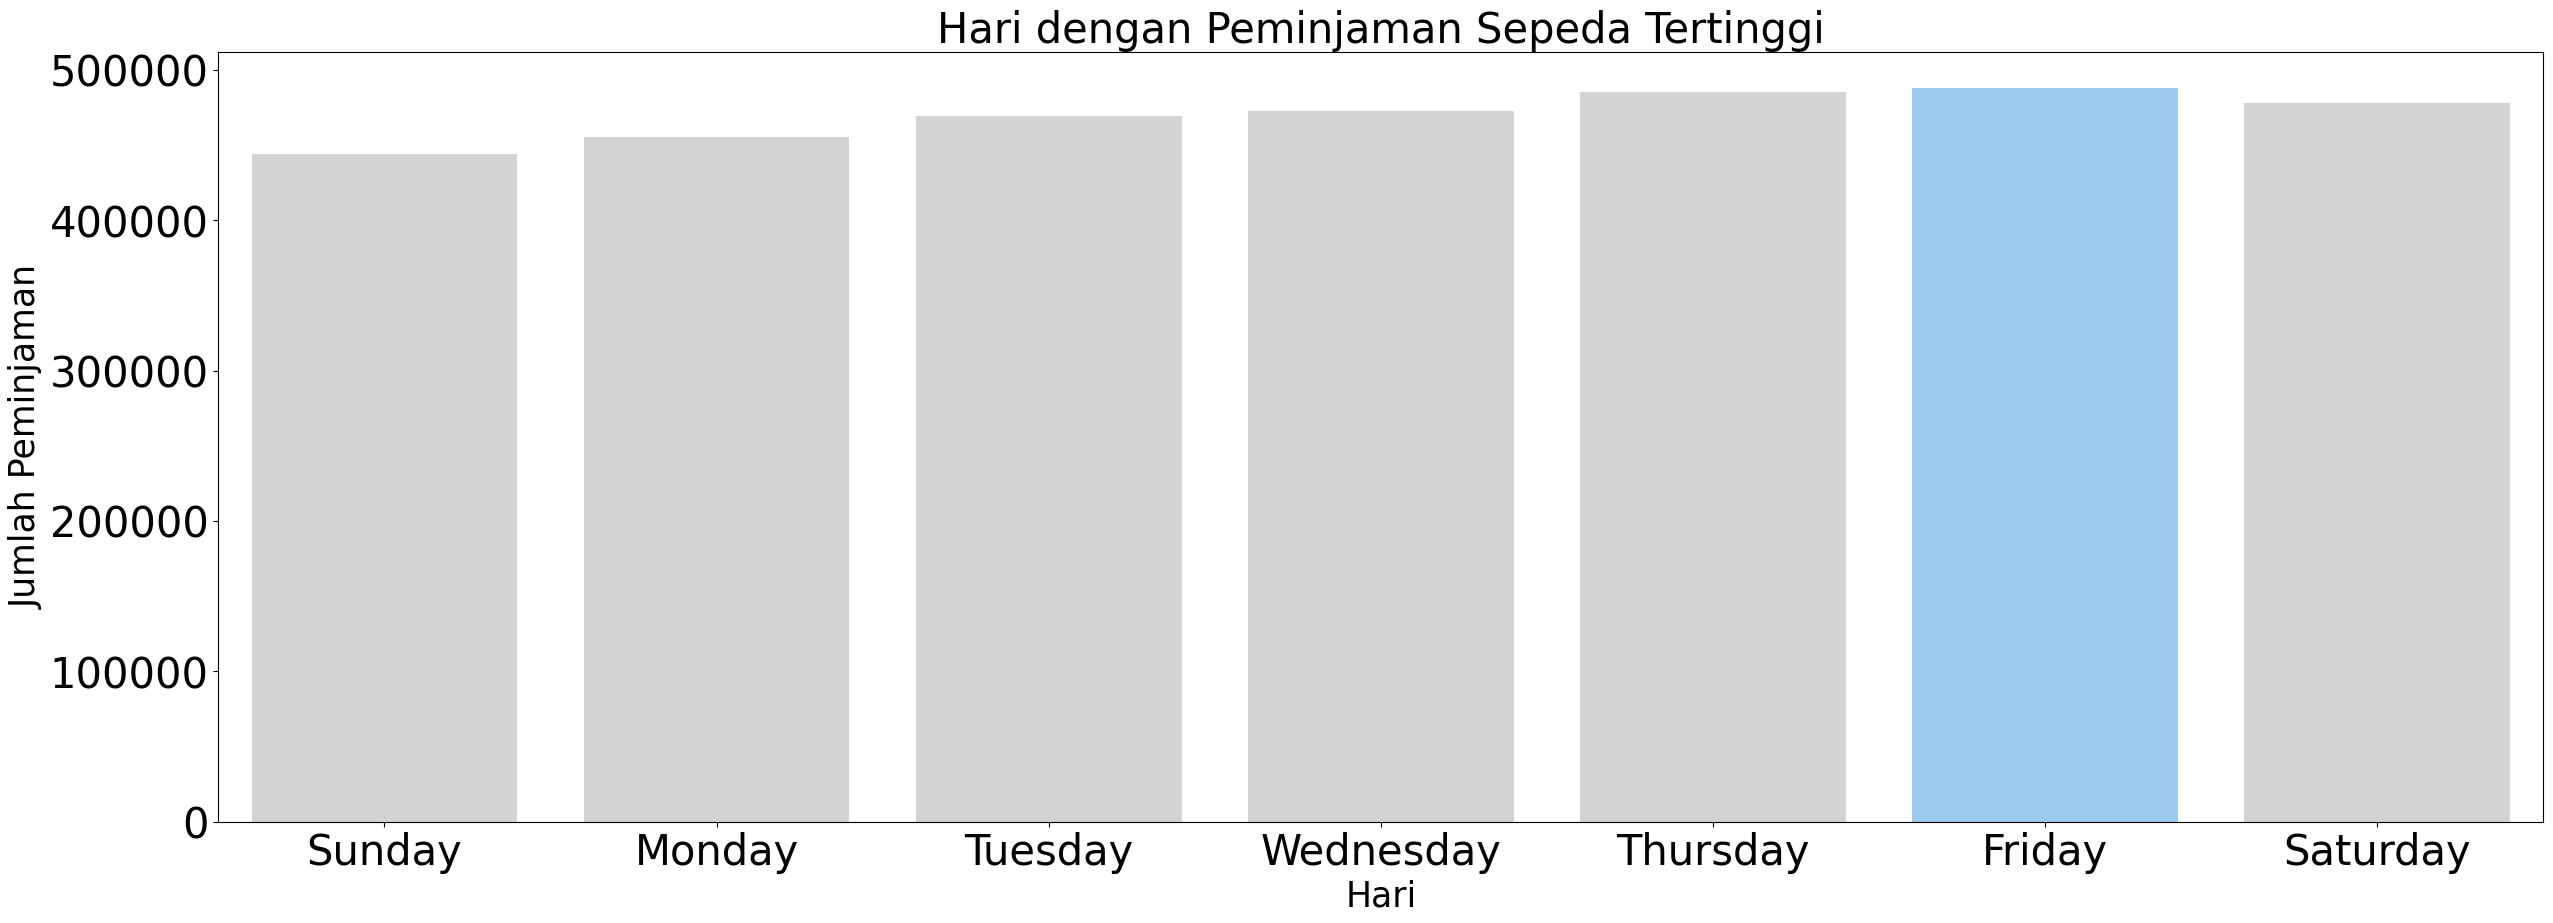

In [ ]:
top_weekdays = sum_weekdays_df.sort_values("count", ascending=False)
low_weekdays = sum_weekdays_df.sort_values("count", ascending=True)

def add_highlight(df, mode="max"):
    target = df["count"].max() if mode == "max" else df["count"].min()
    df = df.copy()
    df["highlight"] = df["count"].apply(
        lambda x: "highlight" if x == target else "other"
    )
    return df

top_weekdays = add_highlight(top_weekdays, mode="max")

fig, ax = plt.subplots(figsize=(30, 10))

palette = {
    "highlight": "#90CAF9",
    "other": "#D3D3D3"
}

sns.barplot(
    x="weekday", y="count",
    data=top_weekdays,
    hue="highlight",
    palette=palette,
    legend=False,
    ax=ax
)

ax.set_title("Hari dengan Peminjaman Sepeda Tertinggi", fontsize=30)
ax.set_xlabel("Hari", fontsize=25)
ax.set_ylabel("Jumlah Peminjaman", fontsize=25)
ax.tick_params(axis='both', labelsize=30)

plt.show()

**Insight:**

Peminjaman sepeda tertinggi terjadi pada hari Jumat, menunjukkan peningkatan mobilitas menjelang akhir pekan, baik untuk aktivitas kerja maupun rekreasi. Sementara itu, peminjaman relatif lebih rendah pada hari Minggu, yang mengindikasikan berkurangnya aktivitas rutin dibandingkan hari kerja.

### Pertanyaan 3: Musim apa yang menghasilkan jumlah peminjaman sepeda terbanyak dan tersedikit?

In [ ]:
sum_seasons_df = (hour_df.groupby("season")["count"].sum().reset_index())

/tmp/ipython-input-3075867194.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_seasons_df = (hour_df.groupby("season")["count"].sum().reset_index())


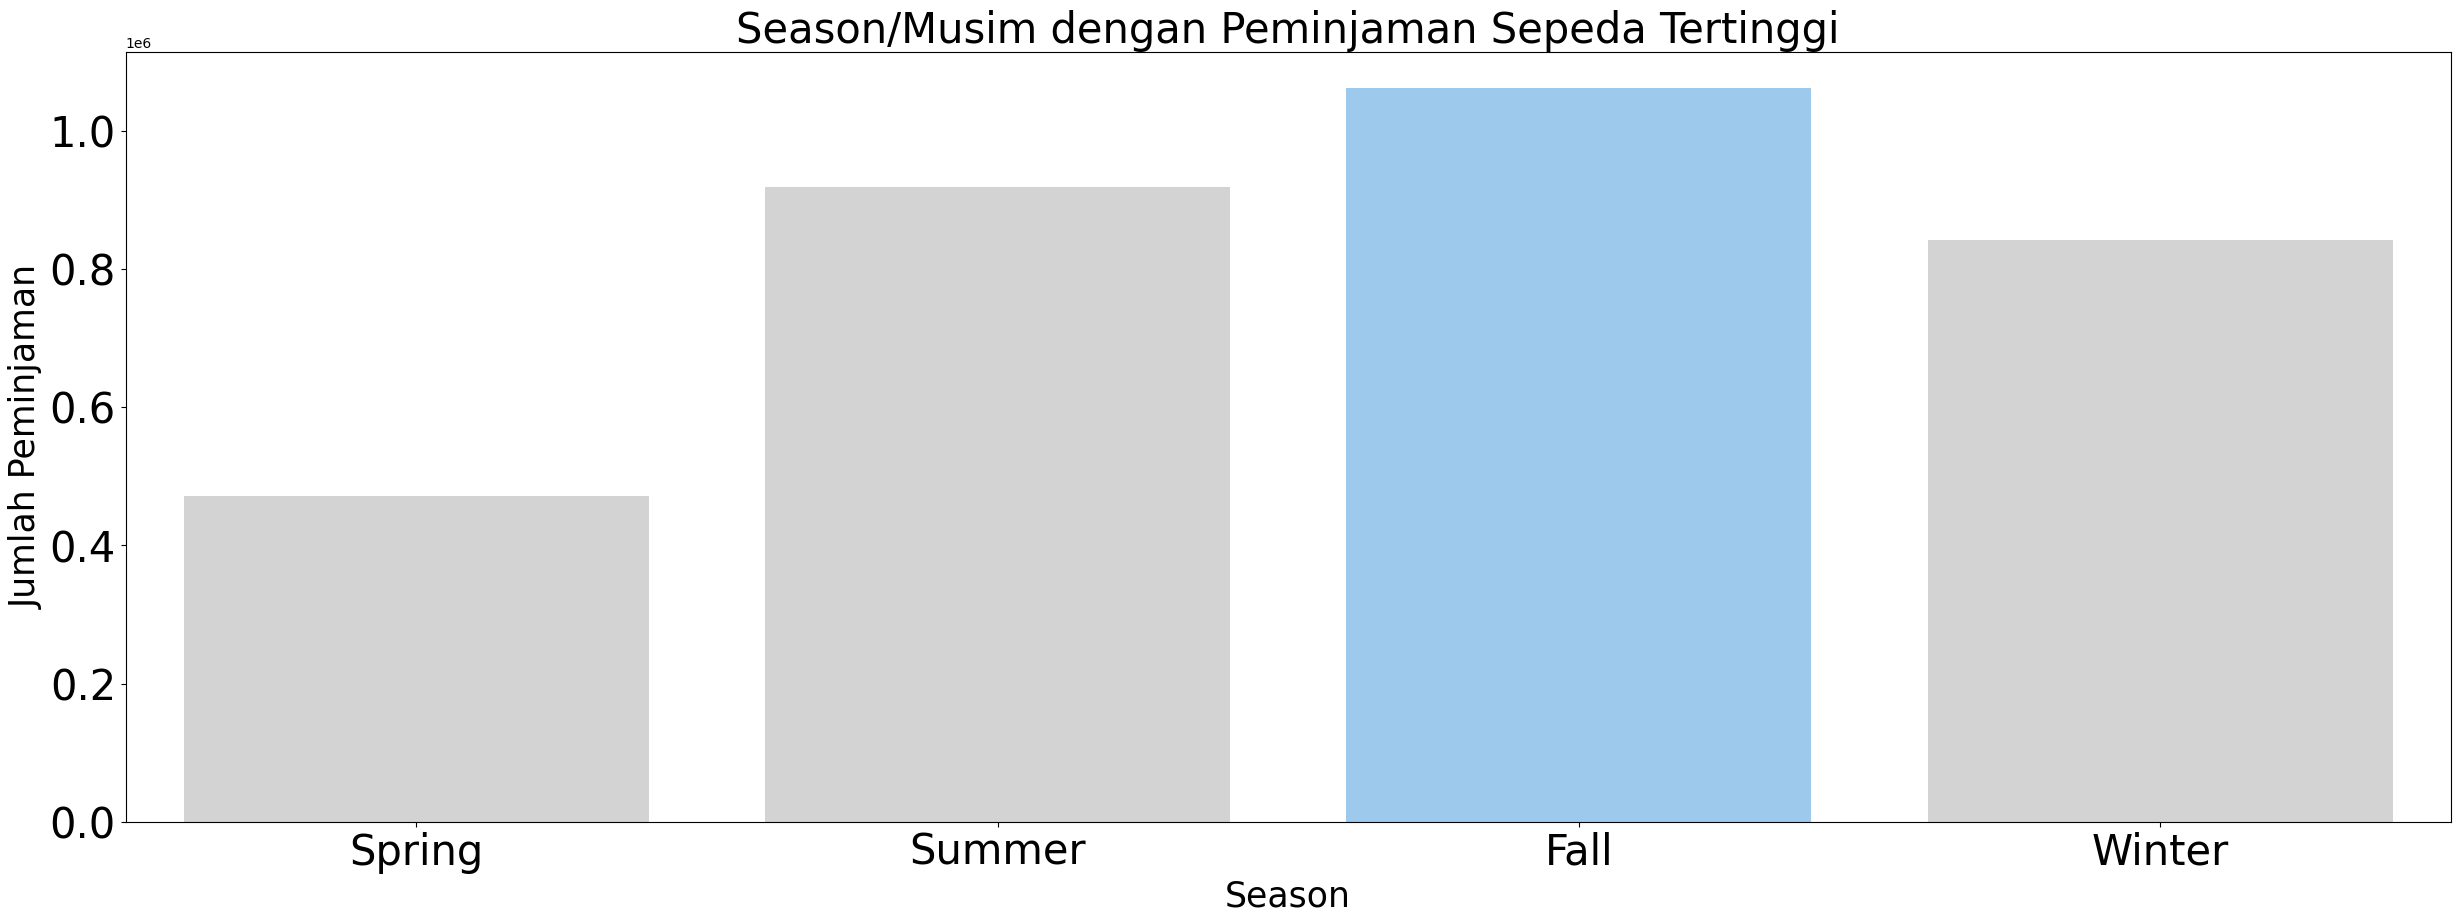

In [ ]:
top_seasons = sum_seasons_df.sort_values("count", ascending=False)
low_seasons = sum_seasons_df.sort_values("count", ascending=True)

def add_highlight(df, mode="max"):
    target = df["count"].max() if mode == "max" else df["count"].min()
    df = df.copy()
    df["highlight"] = df["count"].apply(
        lambda x: "highlight" if x == target else "other"
    )
    return df

top_seasons = add_highlight(top_seasons, mode="max")

fig, ax = plt.subplots(figsize=(30, 10))

palette = {
    "highlight": "#90CAF9",
    "other": "#D3D3D3"
}

sns.barplot(
    x="season", y="count",
    data=top_seasons,
    hue="highlight",
    palette=palette,
    legend=False,
    ax=ax
)

ax.set_title("Season/Musim dengan Peminjaman Sepeda Tertinggi", fontsize=30)
ax.set_xlabel("Season", fontsize=25)
ax.set_ylabel("Jumlah Peminjaman", fontsize=25)
ax.tick_params(axis='both', labelsize=30)

plt.show()

**Insight:**

Peminjaman sepeda tertinggi terjadi pada musim Fall, yang mengindikasikan kondisi cuaca yang lebih nyaman mendorong peningkatan aktivitas bersepeda. Sebaliknya, musim Spring memiliki jumlah peminjaman terendah, kemungkinan dipengaruhi oleh cuaca yang masih kurang stabil. Hal ini menunjukkan bahwa faktor musim dan kenyamanan cuaca berperan besar terhadap tingkat penggunaan sepeda.

### Pertanyaan 4: Bulan apa yang menunjukkan tingkat peminjaman sepeda tertinggi dan terendah?

In [ ]:
sum_months_df = (hour_df.groupby("month")["count"].sum().reset_index())

/tmp/ipython-input-1276029679.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sum_months_df = (hour_df.groupby("month")["count"].sum().reset_index())


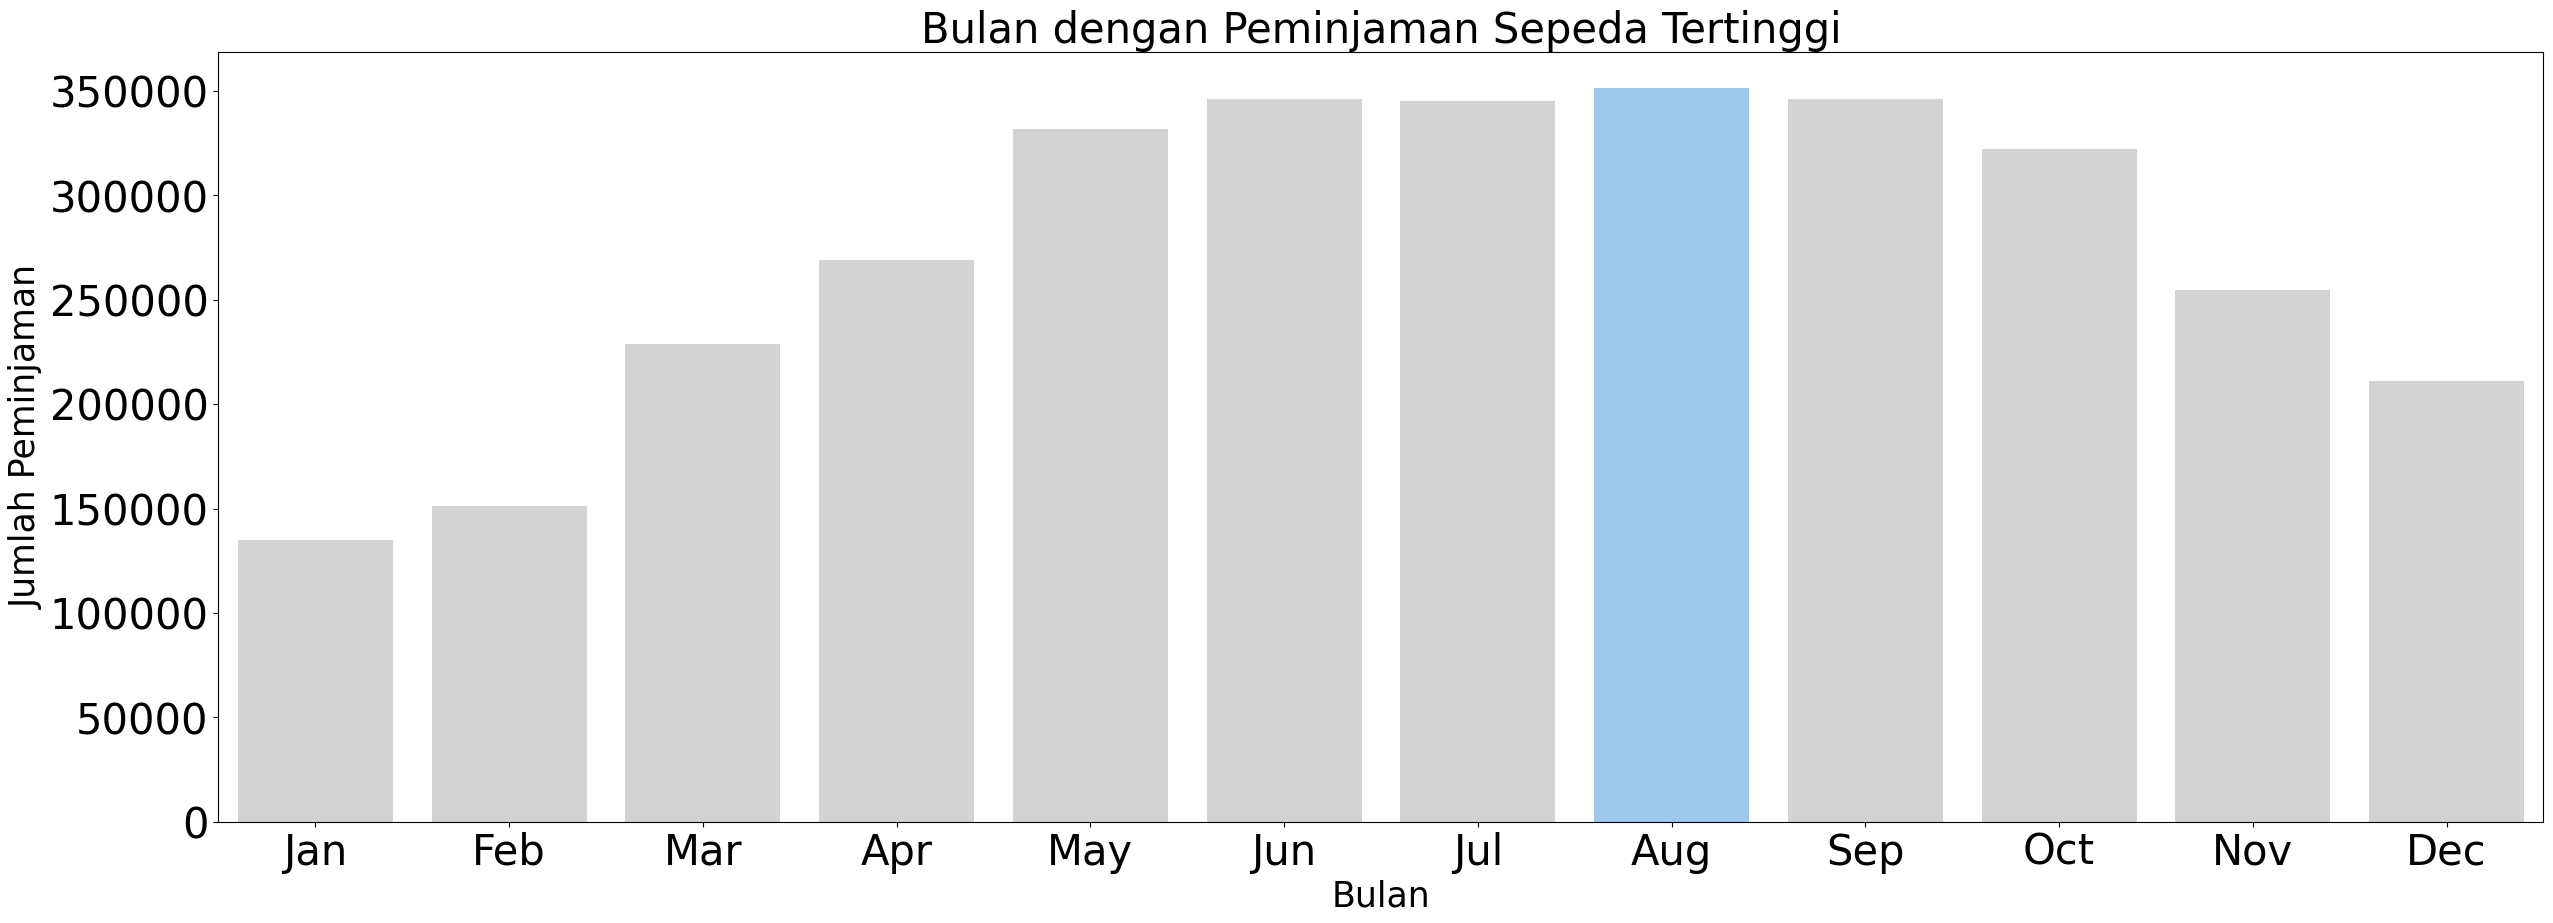

In [ ]:
top_months = sum_months_df.sort_values("count", ascending=False)
low_months = sum_months_df.sort_values("count", ascending=True)

def add_highlight(df, mode="max"):
    target = df["count"].max() if mode == "max" else df["count"].min()
    df = df.copy()
    df["highlight"] = df["count"].apply(
        lambda x: "highlight" if x == target else "other"
    )
    return df

top_months = add_highlight(top_months, mode="max")

fig, ax = plt.subplots(figsize=(30, 10))

palette = {
    "highlight": "#90CAF9",
    "other": "#D3D3D3"
}

sns.barplot(
    x="month", y="count",
    data=top_months,
    hue="highlight",
    palette=palette,
    legend=False,
    ax=ax
)

ax.set_title("Bulan dengan Peminjaman Sepeda Tertinggi", fontsize=30)
ax.set_xlabel("Bulan", fontsize=25)
ax.set_ylabel("Jumlah Peminjaman", fontsize=25)
ax.tick_params(axis='both', labelsize=30)

plt.show()

**Insight:**

Peminjaman sepeda meningkat secara bertahap dari awal tahun dan mencapai puncaknya pada bulan Agustus, menunjukkan tingginya aktivitas bersepeda pada pertengahan tahun. Setelah itu, jumlah peminjaman mulai menurun hingga akhir tahun, yang mengindikasikan adanya pengaruh faktor musiman terhadap minat pengguna.

### Pertanyaan 5: Bagaimana perbandingan jumlah pengguna terdaftar (registered) dan pengguna kasual (casual) dalam peminjaman sepeda?

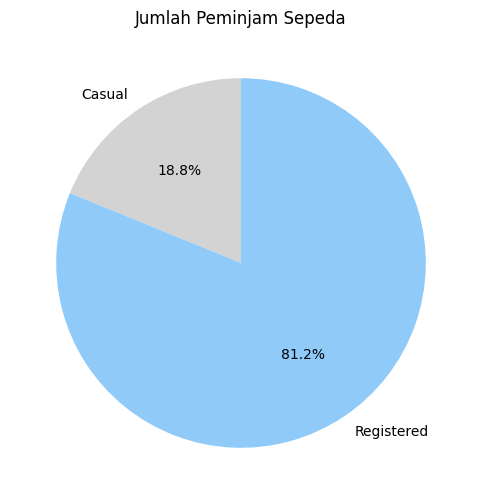

In [ ]:
total_casual = hour_df['casual'].sum()
total_registered = hour_df['registered'].sum()

data = [total_casual, total_registered]
labels = ['Casual', 'Registered']

max_value = max(data)

colors = [
    "#90CAF9" if value == max_value else "#D3D3D3"
    for value in data
]

plt.figure(figsize=(6, 6))
plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title("Jumlah Peminjam Sepeda")
plt.show()

**Insight:**

Sebagian besar peminjaman sepeda didominasi oleh pengguna terdaftar (registered) dengan proporsi sekitar 81%, sedangkan pengguna casual hanya menyumbang sekitar 19%. Hal ini menunjukkan bahwa layanan sepeda lebih banyak dimanfaatkan secara rutin oleh pengguna tetap dibandingkan penggunaan sesekali.

### Pertanyaan 6: Pada kombinasi bulan dan tahun apa jumlah peminjaman sepeda mencapai puncaknya sebagai indikator periode paling menguntungkan bagi pemilik layanan sewa sepeda?

In [ ]:
monthly_rentals = (hour_df.resample(rule="M", on="date").agg(total_rentals=("count", "sum")).reset_index())
monthly_rentals["year_month"] = monthly_rentals["date"].dt.strftime("%Y-%m")

/tmp/ipython-input-1051872607.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rentals = (hour_df.resample(rule="M", on="date").agg(total_rentals=("count", "sum")).reset_index())


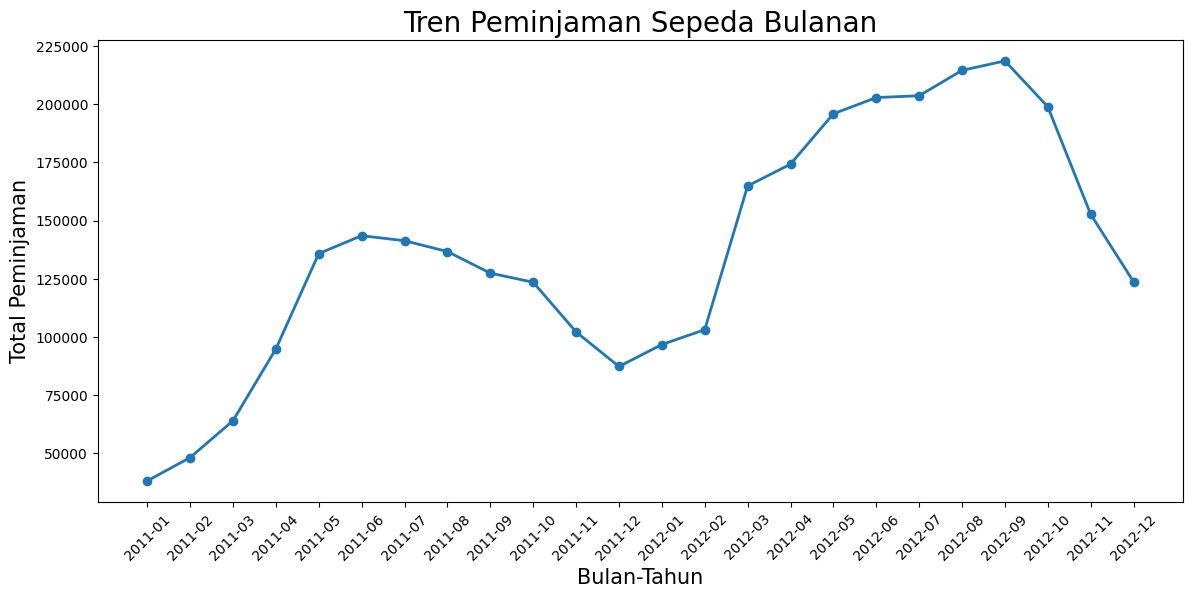

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_rentals["year_month"],
    monthly_rentals["total_rentals"],
    marker="o",
    linewidth=2
)

plt.title("Tren Peminjaman Sepeda Bulanan", fontsize=20)
plt.xlabel("Bulan-Tahun", fontsize=15)
plt.ylabel("Total Peminjaman", fontsize=15)
plt.xticks(rotation=45)
plt.show()

**Insight:**

Tren peminjaman sepeda bulanan menunjukkan adanya peningkatan peminjaman yang konsisten dari awal tahun hingga pertengahan tahun, dengan puncaknya terjadi pada bulan September 2012, yang mengindikasikan periode paling menguntungkan bagi penyedia layanan. Penurunan terlihat pada akhir tahun, terutama memasuki November–Desember, yang kemungkinan dipengaruhi oleh faktor cuaca dan berkurangnya aktivitas luar ruang.

## Analisis Lanjutan (Opsional)

### Analisis Clustering Kelompok Peminjam Berdasarkan Jam/Hour

Pada bagian ini, dilakukan analisis lanjutan yang berupa clustering terhadap data kelompok peminjam berdasarkan waktu, khususnya adalah jam/hour.

In [ ]:
hourly_usage = (hour_df.groupby('hour')['count'].sum()).reset_index()
hourly_usage

,hour,count
0,0,39130
1,1,24164
2,2,16352
3,3,8174
4,4,4428
5,5,14261
6,6,55132
7,7,154171
8,8,261001
9,9,159438


In [ ]:
q1 = hourly_usage["count"].quantile(0.33)
q2 = hourly_usage["count"].quantile(0.66)

def classify_hour_usage(x):
    if x <= q1:
        return "Sepi"
    elif x <= q2:
        return "Normal"
    else:
        return "Sibuk"

hourly_usage["kategori_jam"] = hourly_usage["count"].apply(classify_hour_usage)

hourly_usage

,hour,count,kategori_jam
0,0,39130,Sepi
1,1,24164,Sepi
2,2,16352,Sepi
3,3,8174,Sepi
4,4,4428,Sepi
5,5,14261,Sepi
6,6,55132,Sepi
7,7,154171,Normal
8,8,261001,Sibuk
9,9,159438,Normal


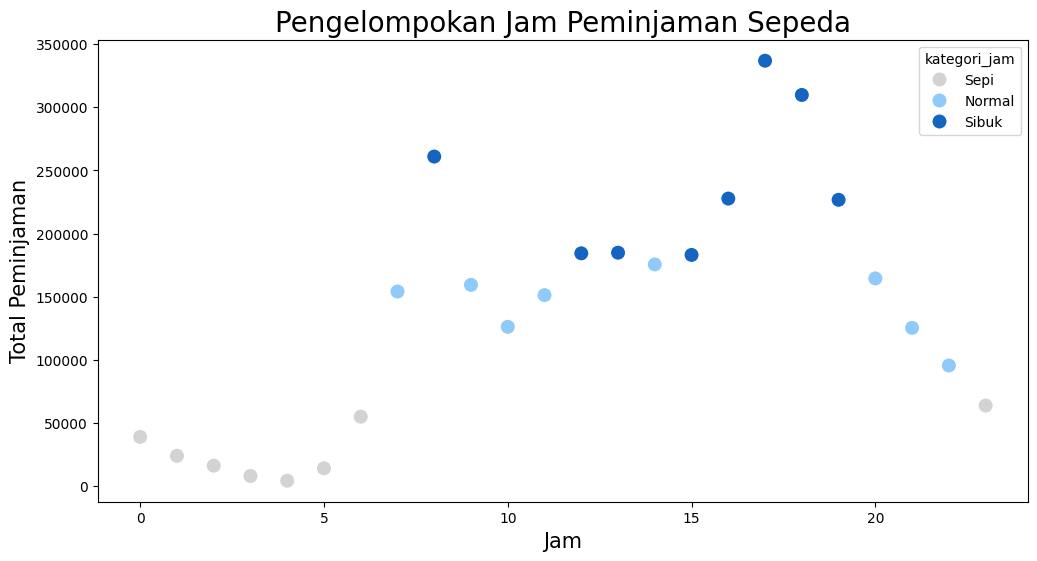

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=hourly_usage,
    x="hour",
    y="count",
    hue="kategori_jam",
    palette={"Sepi": "#D3D3D3", "Normal": "#90CAF9", "Sibuk": "#1565C0"},
    s=120
)

plt.title("Pengelompokan Jam Peminjaman Sepeda", fontsize=20)
plt.xlabel("Jam", fontsize=15)
plt.ylabel("Total Peminjaman", fontsize=15)
plt.show()

**Insight:**

Hasil clustering menunjukkan bahwa aktivitas peminjaman sepeda terbagi jelas menjadi tiga pola waktu, yaitu jam sepi, jam normal, dan jam sibuk. Jam Sepi terkonsentrasi pada dini hari hingga pagi awal (sekitar 00.00–05.00), menandakan rendahnya mobilitas pengguna pada jam tersebut. Jam Normal terjadi pada pagi menjelang siang dan malam hari, sementara jam Sibuk mendominasi sore hingga awal malam (sekitar 16.00–19.00) yang mencerminkan jam pulang kerja dan aktivitas puncak masyarakat.

## Conclusion

1. Pada jam berapa jumlah peminjaman sepeda paling tinggi dan paling rendah?
*   Jam dengan peminjaman tertinggi adalah pukul 17.00 dan sebaliknya peminjaman terendah adalah pukul 04.00.
2. Hari apa dalam seminggu yang memiliki tingkat peminjaman sepeda tertinggi dan terendah?
*   Hari dengan peminjaman tertinggi adalah Jumat dan sebaliknya peminjaman terendah adalah Minggu.
3. Musim apa yang menghasilkan jumlah peminjaman sepeda terbanyak dan tersedikit?
*   Musim dengan peminjaman terbanyak adalah Fall atau gugur dan sebaliknya peminjaman tersedikit adalah Spring atau semi.
4. Bulan apa yang menunjukkan tingkat peminjaman sepeda tertinggi dan terendah?
*   Bulan dengan peminjaman tertinggi adalah Agustus dan sebaliknya peminjaman terendah adalah Januari.
5. Bagaimana perbandingan jumlah pengguna terdaftar (registered) dan pengguna kasual (casual) dalam peminjaman sepeda?
*   Pengguna terdaftar mendominasi peminjaman dengan total 2.672.662, jauh lebih tinggi dibandingkan pengguna kasual sebanyak 620.017.
6. Pada kombinasi bulan dan tahun apa jumlah peminjaman sepeda mencapai puncaknya sebagai indikator periode paling menguntungkan bagi pemilik layanan sewa sepeda?
*   Jumlah peminjaman sepeda mencapai puncak paling menguntungkan pada September 2012, namun penurunannya terjadi pada kisaran bulan November-Desember.